# Twitter Sentiment Analysis: Four Approaches, One Controlled Comparison

Binary sentiment classification on the Sentiment140 dataset (1.6M tweets, positive vs negative).

This notebook compares four models on **identical data and an identical train/test split**:

1. TF-IDF + Logistic Regression (classical, sparse features)
2. Word2Vec + Logistic Regression (classical, dense embeddings)
3. GRU (recurrent neural network)
4. LSTM (recurrent neural network)

The point is the comparison, not any single score. By holding the data, cleaning,
and split constant across all four, the accuracy differences reflect the models
themselves rather than differences in preprocessing. The expected arc: classical
methods in the mid-to-high 70s, deep methods slightly higher, which shows when the
added complexity of a recurrent network actually earns its keep.

In [ ]:
# Section 2: Install non-default dependencies
# gensim is no longer preinstalled on Colab; everything else ships by default.
!pip install -q --upgrade gensim

In [ ]:
# Section 2: Setup
# Imports, global config (single source of truth), GPU check.

import os
import re
import zipfile
import urllib.request

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, LSTM, Dropout, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

from gensim.models import Word2Vec

# ----- Global config: every downstream cell reads from here -----
RANDOM_STATE = 42
TEST_SIZE    = 0.20

# Set to 160000 for the short end-to-end test. Set to None for the full 1.6M run.
SAMPLE_SIZE  = None

# RNN / tokenizer settings (verified)
MAX_WORDS = 10000   # vocab cap for the Keras tokenizer
MAX_LEN   = 40      # token length p99 = 27; 40 is a safe ceiling
EMB_DIM   = 128
BATCH_SIZE = 256

# Word2Vec settings (from the baseline notebook)
W2V_SIZE   = 200
W2V_WINDOW = 10
W2V_MINCNT = 2
W2V_EPOCHS = 10

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# Section 2: Download + load Sentiment140 (de-Drive, runtime path)
# No drive.mount. Downloads to a relative data/ folder, idempotent across re-runs.

DATA_DIR = "data"
ZIP_URL  = "http://cs.stanford.edu/people/alecmgo/trainingandtestdata.zip"
ZIP_PATH = os.path.join(DATA_DIR, "sentiment140.zip")
CSV_PATH = os.path.join(DATA_DIR, "training.1600000.processed.noemoticon.csv")

os.makedirs(DATA_DIR, exist_ok=True)

if not os.path.exists(CSV_PATH):
    print("Downloading Sentiment140 ...")
    req = urllib.request.Request(ZIP_URL, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req) as r, open(ZIP_PATH, "wb") as f:
        f.write(r.read())
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(DATA_DIR)
    print("Download and extract complete.")
else:
    print("CSV already present, skipping download.")

cols = ["target", "ids", "date", "flag", "user", "text"]
df = pd.read_csv(CSV_PATH, encoding="latin-1", names=cols)
df["target"] = df["target"].replace(4, 1)

if SAMPLE_SIZE is not None:
    df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

print(f"rows: {len(df):,}")
print(df["target"].value_counts())
df.head(3)

Download and extract complete.
rows: 1,600,000
target
0    800000
1    800000
Name: count, dtype: int64


,target,ids,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...


In [ ]:
# Section 3: Shared preprocessing + one stratified split
# ONE light-regex clean for all four models. Drop empties BEFORE the split so every
# model trains and tests on the identical row set (and all-zero sequences would crash
# the cuDNN GRU later). ONE stratified split, consumed by every section below.
# This shared data + split is what makes the four-way comparison fair.

def clean_tweet(t):
    t = re.sub(r'@\w+', '', t)          # strip mentions
    t = re.sub(r'http\S+', '', t)       # strip URLs
    t = re.sub(r'[^a-zA-Z\s]', '', t)   # keep letters and whitespace only
    return t.lower().strip()

df['clean'] = df['text'].apply(clean_tweet)

# Drop rows that cleaned down to nothing.
before = len(df)
df = df[df['clean'].str.len() > 0].reset_index(drop=True)
print(f"dropped {before - len(df):,} empty rows, {len(df):,} remain")

# One stratified split. Every downstream model consumes these same text sets.
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean'], df['target'],
    test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=df['target'])

y_train = y_train.values
y_test  = y_test.values

print(f"train: {len(X_train_text):,}   test: {len(X_test_text):,}")
print(f"train balance: {np.bincount(y_train)}")

dropped 3,657 empty rows, 1,596,343 remain
train: 1,277,074   test: 319,269
train balance: [638660 638414]


In [ ]:
# Section 4: TF-IDF + Logistic Regression
# Fit the vectorizer on TRAIN ONLY, then transform test (no test vocab leakage).
# Params carried from the baseline notebook's GridSearch winner: C=1, L2, liblinear.

results = {}   # shared results store; every model section appends to this

tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(X_train_text)   # fit on train only
X_test_tfidf  = tfidf.transform(X_test_text)        # transform test

tfidf_lr = LogisticRegression(C=1, penalty='l2', solver='liblinear', max_iter=500)
tfidf_lr.fit(X_train_tfidf, y_train)

y_pred = tfidf_lr.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
results['TF-IDF + LR'] = acc

print(f"TF-IDF + LR test accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, digits=4))

TF-IDF + LR test accuracy: 0.8059
              precision    recall  f1-score   support

           0     0.8137    0.7935    0.8035    159665
           1     0.7985    0.8183    0.8083    159604

    accuracy                         0.8059    319269
   macro avg     0.8061    0.8059    0.8059    319269
weighted avg     0.8061    0.8059    0.8059    319269



In [ ]:
# Section 5: Word2Vec + Logistic Regression
# Train Word2Vec on TRAIN tokens only, then mean-pool each tweet to one vector.
# Tokens come from the same shared clean (whitespace split), so this is apples-to-apples.

train_tokens = [s.split() for s in X_train_text]
test_tokens  = [s.split() for s in X_test_text]

w2v = Word2Vec(
    sentences=train_tokens,           # fit on train only
    vector_size=W2V_SIZE, window=W2V_WINDOW,
    min_count=W2V_MINCNT, workers=1, epochs=W2V_EPOCHS, seed=RANDOM_STATE)

def vectorize(tokens):
    vecs = [w2v.wv[w] for w in tokens if w in w2v.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(W2V_SIZE)

X_train_w2v = np.array([vectorize(t) for t in train_tokens])
X_test_w2v  = np.array([vectorize(t) for t in test_tokens])

w2v_lr = LogisticRegression(max_iter=1000, class_weight='balanced')
w2v_lr.fit(X_train_w2v, y_train)

y_pred = w2v_lr.predict(X_test_w2v)
acc = accuracy_score(y_test, y_pred)
results['Word2Vec + LR'] = acc

print(f"Word2Vec + LR test accuracy: {acc:.4f}")
print(classification_report(y_test, y_pred, digits=4))

Word2Vec + LR test accuracy: 0.7738
              precision    recall  f1-score   support

           0     0.7744    0.7728    0.7736    159665
           1     0.7732    0.7748    0.7740    159604

    accuracy                         0.7738    319269
   macro avg     0.7738    0.7738    0.7738    319269
weighted avg     0.7738    0.7738    0.7738    319269



In [ ]:
# Section 6: GRU
tok = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tok.fit_on_texts(X_train_text)

X_train_seq = pad_sequences(tok.texts_to_sequences(X_train_text),
                            maxlen=MAX_LEN, padding='post', truncating='post')
X_test_seq  = pad_sequences(tok.texts_to_sequences(X_test_text),
                            maxlen=MAX_LEN, padding='post', truncating='post')

gru = Sequential([
    Embedding(MAX_WORDS, EMB_DIM, mask_zero=True),
    GRU(128),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
gru.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

gru_history = gru.fit(
    X_train_seq, y_train,
    epochs=10, batch_size=BATCH_SIZE,
    validation_split=0.2, callbacks=[early], verbose=1)

acc = accuracy_score(y_test, (gru.predict(X_test_seq) > 0.5).astype(int))
results['GRU'] = acc
print(f"GRU test accuracy: {acc:.4f}")

Epoch 1/10
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 33s 7ms/step - accuracy: 0.8023 - loss: 0.4273 - val_accuracy: 0.8154 - val_loss: 0.4032
Epoch 2/10
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.8235 - loss: 0.3885 - val_accuracy: 0.8197 - val_loss: 0.3947
Epoch 3/10
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 26s 7ms/step - accuracy: 0.8330 - loss: 0.3713 - val_accuracy: 0.8221 - val_loss: 0.3903
Epoch 4/10
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.8413 - loss: 0.3555 - val_accuracy: 0.8226 - val_loss: 0.3908
Epoch 5/10
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 26s 6ms/step - accuracy: 0.8494 - loss: 0.3397 - val_accuracy: 0.8220 - val_loss: 0.3962
9978/9978 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step
GRU test accuracy: 0.8252


In [ ]:
# Section 7: LSTM
# Identical architecture to the GRU, with LSTM(128) swapped in. Reuses the same
# padded sequences (X_train_seq / X_test_seq) and the same EarlyStopping setup,
# so the GRU vs LSTM comparison is clean.

lstm = Sequential([
    Embedding(MAX_WORDS, EMB_DIM, mask_zero=True),
    LSTM(128),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])
lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

early_lstm = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

lstm_history = lstm.fit(
    X_train_seq, y_train,
    epochs=10, batch_size=BATCH_SIZE,
    validation_split=0.2, callbacks=[early_lstm], verbose=1)

acc = accuracy_score(y_test, (lstm.predict(X_test_seq) > 0.5).astype(int))
results['LSTM'] = acc
print(f"LSTM test accuracy: {acc:.4f}")

Epoch 1/10
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 29s 7ms/step - accuracy: 0.8016 - loss: 0.4279 - val_accuracy: 0.8142 - val_loss: 0.4046
Epoch 2/10
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.8226 - loss: 0.3902 - val_accuracy: 0.8193 - val_loss: 0.3961
Epoch 3/10
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.8322 - loss: 0.3725 - val_accuracy: 0.8224 - val_loss: 0.3918
Epoch 4/10
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.8401 - loss: 0.3565 - val_accuracy: 0.8231 - val_loss: 0.3915
Epoch 5/10
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.8481 - loss: 0.3404 - val_accuracy: 0.8227 - val_loss: 0.3977
Epoch 6/10
3991/3991 ━━━━━━━━━━━━━━━━━━━━ 27s 7ms/step - accuracy: 0.8561 - loss: 0.3244 - val_accuracy: 0.8214 - val_loss: 0.4132
9978/9978 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step
LSTM test accuracy: 0.8252


        Model  Test Accuracy
          GRU         0.8252
         LSTM         0.8252
  TF-IDF + LR         0.8059
Word2Vec + LR         0.7738


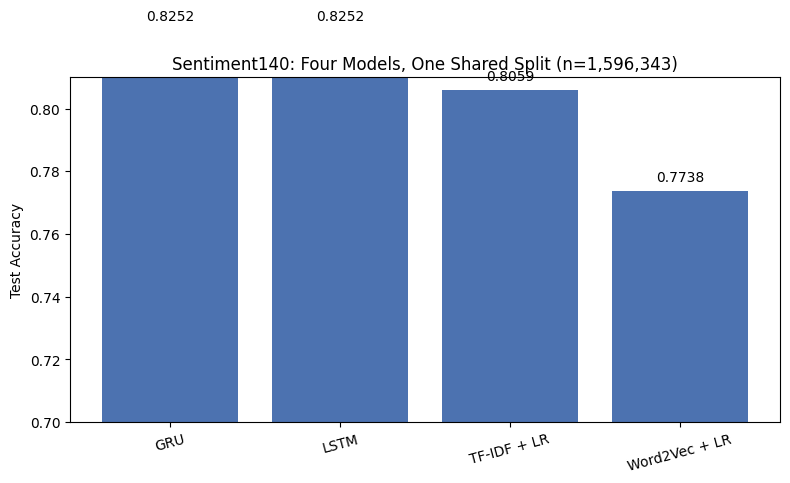

saved results/model_comparison.png


In [ ]:
# Section 8: Results
# Build the comparison table and bar chart from the shared `results` store.
# All four numbers come from the identical clean + split, so this is a fair comparison.
import matplotlib.pyplot as plt

os.makedirs("results", exist_ok=True)

# Ordered best to worst
res_sorted = sorted(results.items(), key=lambda kv: kv[1], reverse=True)
res_df = pd.DataFrame(res_sorted, columns=["Model", "Test Accuracy"])
res_df["Test Accuracy"] = res_df["Test Accuracy"].round(4)
print(res_df.to_string(index=False))

# Bar chart
names = [m for m, _ in res_sorted]
accs  = [a for _, a in res_sorted]

plt.figure(figsize=(8, 5))
bars = plt.bar(names, accs, color="#4C72B0")
plt.ylim(0.70, 0.81)
plt.ylabel("Test Accuracy")
plt.title(f"Sentiment140: Four Models, One Shared Split (n={len(df):,})")
for b, a in zip(bars, accs):
    plt.text(b.get_x() + b.get_width()/2, a + 0.002, f"{a:.4f}",
             ha="center", va="bottom", fontsize=10)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("results/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved results/model_comparison.png")

In [ ]:
# Section 8: Save the trained RNN models (.keras format)
# Only the deep models get saved as files; the classical models live in the notebook.
# NEVER save .h5 (the legacy format tied to the old dead-model versions).
os.makedirs("models", exist_ok=True)

gru.save("models/gru_sentiment.keras")
lstm.save("models/lstm_sentiment.keras")

import os as _os
for f in ["models/gru_sentiment.keras", "models/lstm_sentiment.keras"]:
    print(f, f"{_os.path.getsize(f)/1e6:.1f} MB")

models/gru_sentiment.keras 16.6 MB
models/lstm_sentiment.keras 17.0 MB


In [ ]:
# Section 9: Bundle outputs and download (runtime is ephemeral, no Drive).
# Saves the tokenizer (needed later for the Gradio demo, must match these models),
# then zips models + results + tokenizer and downloads to your machine.
import pickle, zipfile
from google.colab import files

# Save the tokenizer that matches the trained RNNs in this run.
with open("models/tokenizer.pkl", "wb") as f:
    pickle.dump(tok, f)

# Also drop the results table to CSV so the README numbers are exact.
res_df.to_csv("results/results_table.csv", index=False)

bundle = "sentiment_outputs.zip"
with zipfile.ZipFile(bundle, "w", zipfile.ZIP_DEFLATED) as z:
    for path in [
        "models/gru_sentiment.keras",
        "models/lstm_sentiment.keras",
        "models/tokenizer.pkl",
        "results/model_comparison.png",
        "results/results_table.csv",
    ]:
        if os.path.exists(path):
            z.write(path)
            print("added", path)

print(f"\nzip size: {os.path.getsize(bundle)/1e6:.1f} MB")
files.download(bundle)

added models/gru_sentiment.keras
added models/lstm_sentiment.keras
added models/tokenizer.pkl
added results/model_comparison.png
added results/results_table.csv

zip size: 37.6 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>